[1 0]
[[-0.74306799  0.66921593]
 [-0.66921593 -0.74306799]]
(200, 1)
(200, 2)


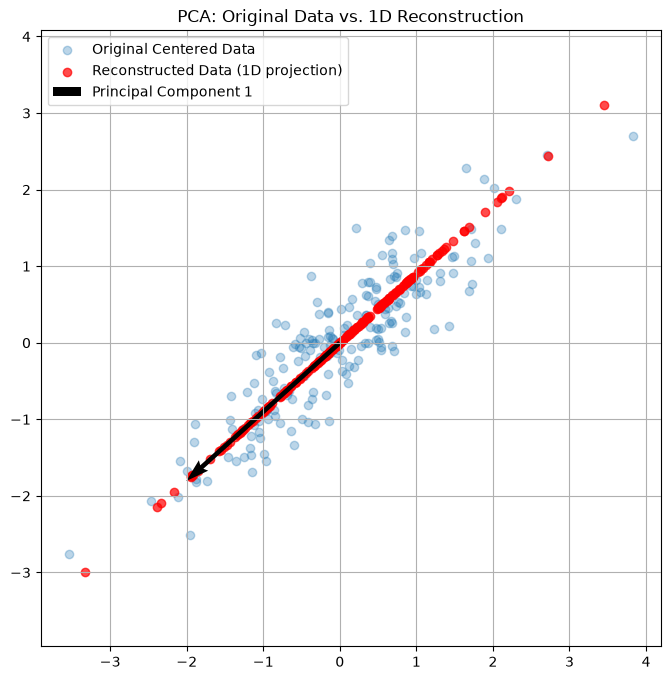

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Set seed for reproducibility
np.random.seed(42)

# Generate 200 samples of 2D data that are highly correlated
X = np.dot(np.random.rand(2, 2), np.random.randn(2, 200)).T
X_fit = PCA(n_components=1).fit(X)
mean = np.mean(X, axis=0)
X_centered = X - mean
cov_matrix = np.transpose(X_centered) @ X_centered / (X_centered.shape[0] - 1)


val, vec = np.linalg.eigh(cov_matrix)

sorted_indices = np.argsort(val)[::-1]
vec = vec[:, sorted_indices]

print(sorted_indices)

print(vec)
vec1 = vec[:, 0]
vec1 = vec1.reshape(2, 1)

X_projected = X_centered.dot(vec1)
print(X_projected.shape)

X_2d_projected = X_projected @ vec1.T

print(X_2d_projected.shape)

plt.figure(figsize=(8, 8))

# 1. Plot the original centered data (light blue dots)
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.3, label="Original Centered Data")

# 2. Plot the reconstructed data (red dots)
plt.scatter(X_2d_projected[:, 0], X_2d_projected[:, 1], color='red', alpha=0.7, label="Reconstructed Data (1D projection)")

#X_reconstructed = X_fit.inverse_transform(X_fit.transform(X))
#plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], color='red', alpha=0.7, label="Reconstructed Data (1D projection)")

# 3. Draw the Principal Component vector (the axis we kept)
origin = [0, 0]
plt.quiver(*origin, *vec1, color=['black'], scale=3, label="Principal Component 1")

plt.axis('equal')
plt.legend()
plt.title("PCA: Original Data vs. 1D Reconstruction")
plt.grid(True)
plt.show()


ModuleNotFoundError: No module named 'weasyprint'